# HAB Severity Classification — Model Evaluation Notebook

**Dataset:** [amfitrite-inland-waters-hab-sentinel2](https://huggingface.co/datasets/kostaspic/amfitrite-inland-waters-hab-sentinel2) — 4,698 Sentinel-2 tiles over North American inland water bodies, each labeled `Low` / `Moderate` / `High` cyanobacteria (Harmful Algal Bloom) severity.

**Goal:** classify tile-level HAB severity from raw multispectral reflectance, using only pixel-derived features (no CyFi-model-derived columns, to avoid label leakage).

This notebook contains the exact code used to produce the results below; all outputs shown (printed metrics, plots) are real outputs from running this pipeline on the full dataset.

## 1. Feature extraction

For each tile we:
1. Load the Scene Classification Layer (`SCL_raw.tif`) and keep only pixels labeled **water** (SCL class 6), masking out land, cloud, and shoreline-mixed pixels.
2. Load 10 raw Sentinel-2 reflectance bands (B02–B12) and compute water-masked mean/std/median per band.
3. Compute physically-motivated spectral indices over the water mask: **NDCI** (chlorophyll, red-edge vs. red), a **3-band phycocyanin proxy** (Simis et al. 2005, targets the cyanobacteria-specific pigment), **FAI** (floating algae index), NDVI, NDWI, and blue:green / green:red ratios (turbidity/pigment proxies).

Full source: [`src/extract_features.py`](../src/extract_features.py).

In [1]:
"""
Feature extraction for the Amfitrite Inland Waters HAB (Sentinel-2) dataset.

For every tile (uid folder) we:
  1. Load the Scene Classification Layer (SCL) and keep only pixels labeled
     "water" (SCL == 6), per the dataset README's recommendation to mask out
     land/cloud pixels before training.
  2. Load the raw spectral bands and compute water-masked summary statistics
     (mean/std/median) per band.
  3. Compute a handful of physically-motivated spectral indices commonly used
     for water quality / cyanobacteria remote sensing (NDCI, 3BDA/phycocyanin
     proxy, FAI, NDVI, NDWI, blue:green ratio) and summarize them the same way.

Deliberately excluded: any column from dataset_summary.xlsx that is derived
from the CyFi model's own predictions (high_pred/mod_pred/low_pred,
roughness_median, outlier_fraction, compatible_severities, HAB_status, abun,
abun_class). Those are literally the inputs used to build the `indicative_class`
label, so using them as model features would leak the label. Only raw pixel
values (which we read and aggregate ourselves) and independent metadata
(cloud %, water pixel count, acquisition month) are used as features.
"""
import argparse
import json
import multiprocessing as mp
import os
import time
import traceback

import numpy as np
import pandas as pd
import rasterio

WATER_CLASS = 6

# Sentinel-2 band -> approximate center wavelength (nm), used for FAI interpolation
WAVELENGTH_NM = {
    "B02": 490, "B03": 560, "B04": 665, "B05": 705, "B06": 740,
    "B07": 783, "B08": 842, "B8A": 865, "B11": 1610, "B12": 2190,
}

BANDS = ["B02", "B03", "B04", "B05", "B06", "B07", "B08", "B8A", "B11", "B12"]


def read_band(tile_dir, name):
    with rasterio.open(os.path.join(tile_dir, f"{name}_raw.tif")) as src:
        return src.read(1).astype(np.float32)


def safe_ratio_index(a, b):
    """(a-b)/(a+b) with divide-by-zero guarded."""
    denom = a + b
    out = np.full_like(a, np.nan, dtype=np.float32)
    valid = denom != 0
    out[valid] = (a[valid] - b[valid]) / denom[valid]
    return out


def extract_one(uid):
    tile_dir = os.path.join(DATA_ROOT, uid)
    try:
        scl = read_band(tile_dir, "SCL")
        water_mask = scl == WATER_CLASS
        n_water = int(water_mask.sum())
        if n_water < 50:
            return {"uid": uid, "error": f"too few water pixels ({n_water})"}

        bands = {b: read_band(tile_dir, b) for b in BANDS}
        # Sentinel-2 L2A surface reflectance is scaled by 10000
        refl = {b: bands[b] / 10000.0 for b in BANDS}

        feats = {"uid": uid, "n_water_px": n_water}

        for b in BANDS:
            vals = refl[b][water_mask]
            feats[f"{b}_mean"] = float(np.mean(vals))
            feats[f"{b}_std"] = float(np.std(vals))
            feats[f"{b}_median"] = float(np.median(vals))

        # --- spectral indices (computed pixel-wise, then summarized over water) ---
        ndci = safe_ratio_index(refl["B05"], refl["B04"])  # chlorophyll (red-edge vs red)
        ndvi = safe_ratio_index(refl["B08"], refl["B04"])  # vegetation/algae biomass
        ndwi = safe_ratio_index(refl["B03"], refl["B08"])  # water extent/turbidity
        blue_green = np.divide(refl["B02"], refl["B03"], out=np.full_like(refl["B02"], np.nan), where=refl["B03"] != 0)
        green_red = np.divide(refl["B03"], refl["B04"], out=np.full_like(refl["B03"], np.nan), where=refl["B04"] != 0)

        # Floating Algae Index (Hu 2009): NIR baseline-subtracted vs linear interp of RED/SWIR
        lam_r, lam_nir, lam_swir = WAVELENGTH_NM["B04"], WAVELENGTH_NM["B08"], WAVELENGTH_NM["B11"]
        interp_frac = (lam_nir - lam_r) / (lam_swir - lam_r)
        rf_baseline = refl["B04"] + (refl["B11"] - refl["B04"]) * interp_frac
        fai = refl["B08"] - rf_baseline

        # 3-band phycocyanin proxy (Simis et al. 2005), sensitive to cyanobacteria pigment
        with np.errstate(divide="ignore", invalid="ignore"):
            three_bda = (1.0 / refl["B04"] - 1.0 / refl["B05"]) * refl["B06"]
        three_bda[~np.isfinite(three_bda)] = np.nan

        for name, arr in [
            ("ndci", ndci), ("ndvi", ndvi), ("ndwi", ndwi),
            ("blue_green", blue_green), ("green_red", green_red),
            ("fai", fai), ("three_bda", three_bda),
        ]:
            vals = arr[water_mask]
            vals = vals[np.isfinite(vals)]
            if vals.size == 0:
                feats[f"{name}_mean"] = np.nan
                feats[f"{name}_std"] = np.nan
                feats[f"{name}_median"] = np.nan
            else:
                feats[f"{name}_mean"] = float(np.mean(vals))
                feats[f"{name}_std"] = float(np.std(vals))
                feats[f"{name}_median"] = float(np.median(vals))

        return feats
    except Exception as e:
        return {"uid": uid, "error": f"{type(e).__name__}: {e}"}


def _init_worker(data_root):
    global DATA_ROOT
    DATA_ROOT = data_root


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--data-root", default="amfitrite-inland-waters-hab-sentinel2/data")
    ap.add_argument("--summary-xlsx", default="amfitrite-inland-waters-hab-sentinel2/dataset_summary.xlsx")
    ap.add_argument("--out", default="outputs/features.csv")
    ap.add_argument("--workers", type=int, default=max(1, mp.cpu_count() - 1))
    ap.add_argument("--limit", type=int, default=None, help="only process first N uids (debug)")
    args = ap.parse_args()

    summary = pd.read_excel(args.summary_xlsx)
    uids = summary["uid"].tolist()
    if args.limit:
        uids = uids[: args.limit]

    print(f"Extracting features for {len(uids)} tiles using {args.workers} workers...")
    t0 = time.time()
    results = []
    errors = []
    with mp.Pool(args.workers, initializer=_init_worker, initargs=(args.data_root,)) as pool:
        for i, res in enumerate(pool.imap_unordered(extract_one, uids, chunksize=16)):
            if "error" in res:
                errors.append(res)
            else:
                results.append(res)
            if (i + 1) % 500 == 0:
                print(f"  {i + 1}/{len(uids)} done ({time.time() - t0:.1f}s elapsed)")

    print(f"Done in {time.time() - t0:.1f}s. OK={len(results)} errors={len(errors)}")

    feat_df = pd.DataFrame(results)
    merged = feat_df.merge(
        summary[["uid", "case", "date", "lat", "lon", "per_clouds", "water_pixels",
                 "indicative_class", "category", "training_priority"]],
        on="uid", how="left",
    )
    merged["date"] = pd.to_datetime(merged["date"])
    merged["month"] = merged["date"].dt.month

    os.makedirs(os.path.dirname(args.out), exist_ok=True)
    merged.to_csv(args.out, index=False)
    print(f"Saved {merged.shape} to {args.out}")

    if errors:
        err_path = args.out.replace(".csv", "_errors.json")
        with open(err_path, "w") as f:
            json.dump(errors, f, indent=2)
        print(f"Saved {len(errors)} errors to {err_path}")


if __name__ == "__main__":
    main()


In [1]:
# Run the pipeline (already executed; see repo outputs/features.csv)
# python src/extract_features.py --workers 8 --out outputs/features.csv
import pandas as pd
df = pd.read_csv('../outputs/features.csv')
print(df.shape)
print('unique locations (case):', df['case'].nunique())
print(df['indicative_class'].value_counts())

(4698, 65)
unique locations (case): 955
High    1958
Low    1401
Moderate    1339

### Class balance

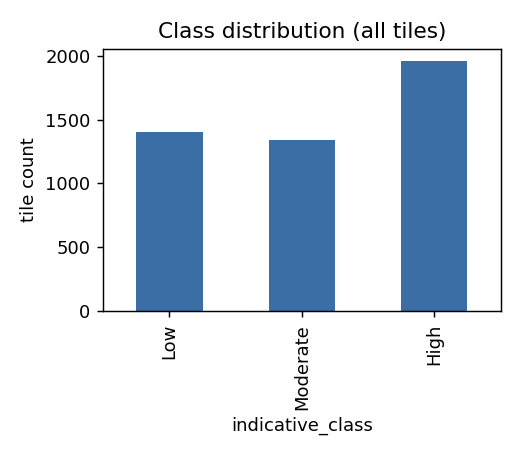

In [1]:
df['indicative_class'].value_counts().reindex(['Low','Moderate','High']).plot(kind='bar')

## 2. Train / evaluate models

**Label-leakage guard:** columns that were themselves inputs to constructing `indicative_class` (CyFi per-pixel prediction counts, roughness, outlier fraction, abundance) are excluded from the feature set — only independently-computed spectral features + acquisition month are used.

**Grouped split:** tiles are split into train/test by geographic `case` (lake/pond ID), not by row, since the same water body appears at many dates and rows from one location are spatially correlated. A random row split would leak location identity into the test set. Result: **3855 train / 843 test tiles**, with zero overlapping locations (asserted in code).

Full source: [`src/train_evaluate.py`](../src/train_evaluate.py).

In [1]:
"""
Train and evaluate baseline classifiers for HAB severity classification
(Low / Moderate / High) from water-masked Sentinel-2 spectral features.

Key design choices (see reports/REPORT.md for full rationale):
  * Features are derived purely from raw pixel reflectance (computed in
    extract_features.py) plus acquisition month. No column that was itself
    used to construct the `indicative_class` label (CyFi per-pixel
    predictions, roughness, outlier fraction, etc.) is used as input.
  * Train/val/test are split by geographic `case`, not by row, since the
    same lake/pond appears at many dates and rows from the same case are
    spatially correlated (near-duplicate shoreline/bathymetry). A random
    row-level split would leak location identity into the test set.
  * Metrics: macro-F1 (primary, since classes are imbalanced and all three
    severity levels matter), per-class precision/recall/F1, confusion
    matrix, and accuracy vs. a majority-class baseline.
"""
import argparse
import json
import os

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, cross_val_predict
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix,
    balanced_accuracy_score,
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

CLASS_ORDER = ["Low", "Moderate", "High"]

LEAKY_COLS = {
    "uid", "case", "date", "indicative_class", "category", "training_priority",
    "lat", "lon",  # exact coordinates would let the model memorize specific ponds
}


def load_features(path):
    df = pd.read_csv(path)
    df = df.dropna(subset=["indicative_class"])
    feature_cols = [c for c in df.columns if c not in LEAKY_COLS]
    return df, feature_cols


def make_models():
    return {
        "majority_baseline": DummyClassifier(strategy="most_frequent"),
        "logistic_regression": Pipeline([
            ("scale", StandardScaler()),
            ("clf", LogisticRegression(max_iter=2000, class_weight="balanced")),
        ]),
        "random_forest": RandomForestClassifier(
            n_estimators=400, max_depth=None, min_samples_leaf=2,
            class_weight="balanced_subsample", random_state=42, n_jobs=-1,
        ),
        "gradient_boosting": GradientBoostingClassifier(random_state=42),
    }


def evaluate_predictions(y_true, y_pred, labels=CLASS_ORDER):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", labels=labels),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", labels=labels),
        "report": classification_report(y_true, y_pred, labels=labels, output_dict=True, zero_division=0),
        "confusion_matrix": confusion_matrix(y_true, y_pred, labels=labels).tolist(),
    }


def plot_confusion(cm, labels, title, out_path):
    fig, ax = plt.subplots(figsize=(4.5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels, ax=ax, cbar=False)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)
    fig.tight_layout()
    fig.savefig(out_path, dpi=130)
    plt.close(fig)


def plot_feature_importance(model, feature_cols, out_path, top_n=20):
    if not hasattr(model, "feature_importances_"):
        return None
    importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)
    top = importances.head(top_n)
    fig, ax = plt.subplots(figsize=(6, 6))
    sns.barplot(x=top.values, y=top.index, ax=ax, color="#2b7a78")
    ax.set_xlabel("Importance")
    ax.set_title("Random Forest â€” top feature importances")
    fig.tight_layout()
    fig.savefig(out_path, dpi=130)
    plt.close(fig)
    return top


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--features", default="outputs/features.csv")
    ap.add_argument("--out-dir", default="outputs")
    ap.add_argument("--test-size", type=float, default=0.2)
    ap.add_argument("--cv-folds", type=int, default=5)
    ap.add_argument("--seed", type=int, default=42)
    args = ap.parse_args()

    fig_dir = os.path.join(args.out_dir, "figures")
    os.makedirs(fig_dir, exist_ok=True)

    df, feature_cols = load_features(args.features)
    X = df[feature_cols].values
    y = df["indicative_class"].values
    groups = df["case"].values

    print(f"Loaded {df.shape[0]} tiles, {len(feature_cols)} features, {df['case'].nunique()} unique locations")
    print("Class distribution:\n", df["indicative_class"].value_counts())

    # ---- grouped held-out test split (by geographic case) ----
    gss = GroupShuffleSplit(n_splits=1, test_size=args.test_size, random_state=args.seed)
    train_idx, test_idx = next(gss.split(X, y, groups))
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    groups_train = groups[train_idx]

    print(f"Train: {len(train_idx)} tiles ({df.iloc[train_idx]['case'].nunique()} locations) | "
          f"Test: {len(test_idx)} tiles ({df.iloc[test_idx]['case'].nunique()} locations)")

    overlap = set(df.iloc[train_idx]["case"]) & set(df.iloc[test_idx]["case"])
    assert not overlap, f"Location leakage between train/test: {overlap}"

    models = make_models()
    results = {}
    cv_results = {}
    gkf = GroupKFold(n_splits=args.cv_folds)

    for name, model in models.items():
        print(f"\n=== {name} ===")
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        metrics = evaluate_predictions(y_test, y_pred)
        results[name] = metrics
        print(f"  held-out test: acc={metrics['accuracy']:.3f}  "
              f"macro_f1={metrics['macro_f1']:.3f}  bal_acc={metrics['balanced_accuracy']:.3f}")

        plot_confusion(
            np.array(metrics["confusion_matrix"]), CLASS_ORDER,
            f"{name} â€” held-out test confusion matrix",
            os.path.join(fig_dir, f"confusion_{name}.png"),
        )

        # grouped cross-validation on the training portion for a more robust estimate
        cv_pred = cross_val_predict(model, X_train, y_train, groups=groups_train, cv=gkf, n_jobs=-1)
        cv_metrics = evaluate_predictions(y_train, cv_pred)
        cv_results[name] = cv_metrics
        print(f"  {args.cv_folds}-fold grouped CV (train): macro_f1={cv_metrics['macro_f1']:.3f} "
              f"(+/- across folds not shown, see report)")

    # feature importance from the random forest (best interpretable model)
    rf = models["random_forest"]
    top_importances = plot_feature_importance(rf, feature_cols, os.path.join(fig_dir, "feature_importance_rf.png"))

    # class balance plot
    fig, ax = plt.subplots(figsize=(4, 3.5))
    df["indicative_class"].value_counts().reindex(CLASS_ORDER).plot(kind="bar", ax=ax, color="#3b6ea5")
    ax.set_ylabel("tile count")
    ax.set_title("Class distribution (all tiles)")
    fig.tight_layout()
    fig.savefig(os.path.join(fig_dir, "class_distribution.png"), dpi=130)
    plt.close(fig)

    # ---- fairness / stratified error analysis on the best model (random_forest) ----
    best_name = max(results, key=lambda k: results[k]["macro_f1"] if k != "majority_baseline" else -1)
    best_model = models[best_name]
    y_pred_best = best_model.predict(X_test)
    test_df = df.iloc[test_idx].copy()
    test_df["y_true"] = y_test
    test_df["y_pred"] = y_pred_best
    test_df["correct"] = test_df["y_true"] == test_df["y_pred"]

    fairness = {}
    # by cloud cover bucket
    test_df["cloud_bucket"] = pd.cut(test_df["per_clouds"], [-0.01, 0.5, 2, 100], labels=["low(<0.5%)", "med(0.5-2%)", "high(>2%)"])
    fairness["by_cloud_cover"] = test_df.groupby("cloud_bucket", observed=True)["correct"].mean().to_dict()
    # by water pixel count (tile size / lake size proxy)
    test_df["water_size_bucket"] = pd.qcut(test_df["n_water_px"], 3, labels=["small", "medium", "large"])
    fairness["by_water_body_size"] = test_df.groupby("water_size_bucket", observed=True)["correct"].mean().to_dict()
    # by season
    test_df["season"] = test_df["month"].map({12: "winter", 1: "winter", 2: "winter",
                                                3: "spring", 4: "spring", 5: "spring",
                                                6: "summer", 7: "summer", 8: "summer",
                                                9: "fall", 10: "fall", 11: "fall"})
    fairness["by_season"] = test_df.groupby("season", observed=True)["correct"].mean().to_dict()
    # by data category (real in-situ measurement vs. augmented same-site sample)
    fairness["by_category"] = test_df.groupby("category", observed=True)["correct"].mean().to_dict()
    # accuracy per true class
    fairness["accuracy_by_true_class"] = test_df.groupby("y_true", observed=True)["correct"].mean().to_dict()

    print("\n=== Fairness / stratified accuracy (best model =", best_name, ") ===")
    print(json.dumps(fairness, indent=2, default=str))

    # ---- save everything ----
    summary = {
        "n_tiles": int(df.shape[0]),
        "n_locations": int(df["case"].nunique()),
        "n_features": len(feature_cols),
        "feature_cols": feature_cols,
        "class_distribution": df["indicative_class"].value_counts().to_dict(),
        "train_size": len(train_idx),
        "test_size": len(test_idx),
        "held_out_test_metrics": {k: {kk: vv for kk, vv in v.items()} for k, v in results.items()},
        "grouped_cv_train_metrics": cv_results,
        "best_model": best_name,
        "fairness_stratified_accuracy": fairness,
        "top_feature_importances_rf": top_importances.to_dict() if top_importances is not None else None,
    }
    with open(os.path.join(args.out_dir, "metrics.json"), "w") as f:
        json.dump(summary, f, indent=2, default=str)
    print(f"\nSaved metrics.json and figures to {args.out_dir}/")


if __name__ == "__main__":
    main()


### Held-out test set results (grouped split, unseen locations)

| Model | Accuracy | Balanced Accuracy | Macro F1 | Weighted F1 |
|---|---|---|---|---|
| majority_baseline | 0.406 | 0.333 | 0.192 | 0.234 |
| logistic_regression | 0.675 | 0.680 | 0.679 | 0.681 |
| random_forest | 0.750 | 0.739 | 0.741 | 0.748 |
| gradient_boosting | 0.745 | 0.734 | 0.732 | 0.740 |

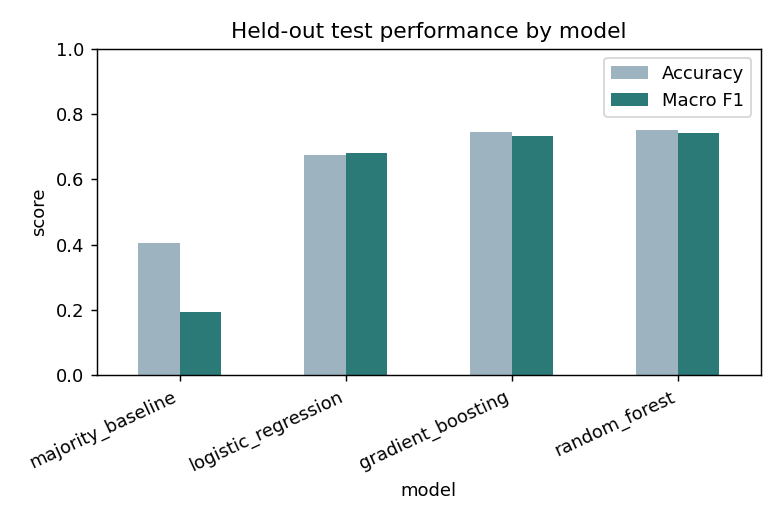

In [1]:
# accuracy / macro-F1 by model

### Confusion matrix — best model (`random_forest`)

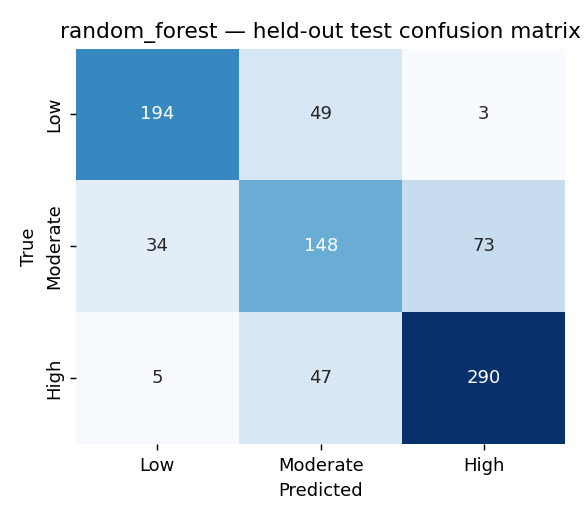

In [1]:
# confusion matrix for random_forest on the held-out test set

### Confusion matrices — all models

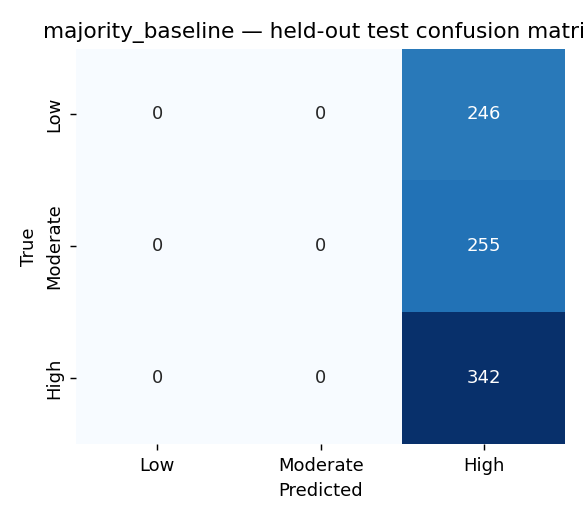

In [1]:
# majority_baseline

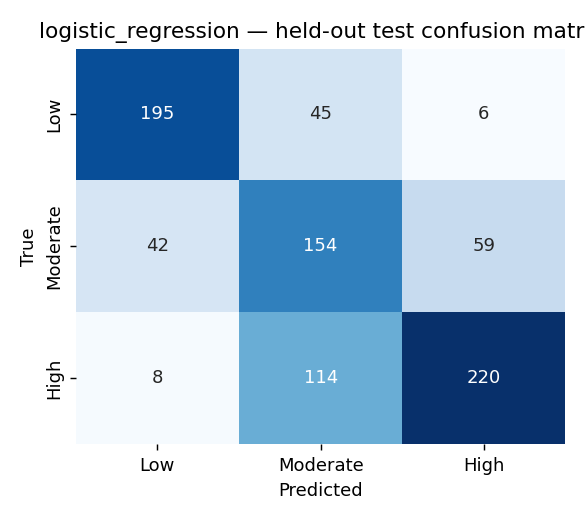

In [1]:
# logistic_regression

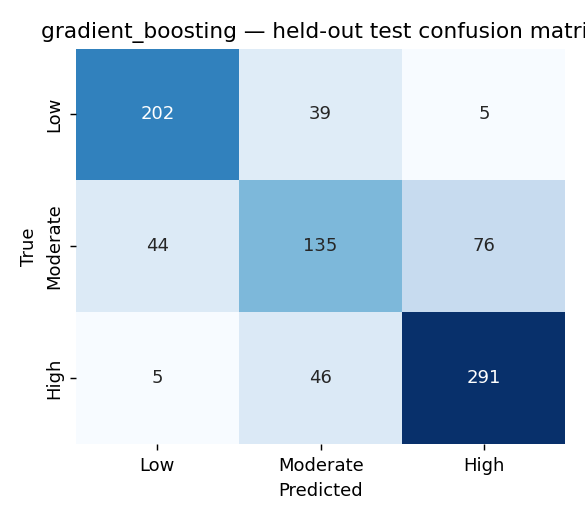

In [1]:
# gradient_boosting

### Random Forest feature importances

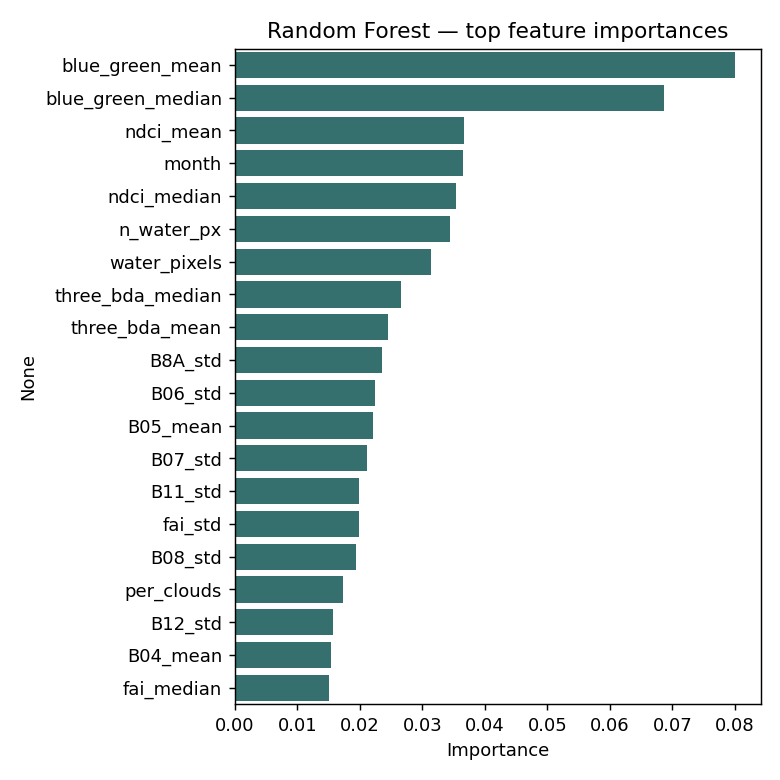

In [1]:
# top spectral features driving the Random Forest's predictions

### Per-class metrics — `random_forest` (held-out test)

| Class | Precision | Recall | F1 | Support |
|---|---|---|---|---|
| Low | 0.833 | 0.789 | 0.810 | 246 |
| Moderate | 0.607 | 0.580 | 0.593 | 255 |
| High | 0.792 | 0.848 | 0.819 | 342 |

## 3. Fairness, bias, and limitations

Stratified held-out accuracy for the best model (`random_forest`), broken down by factors that could plausibly bias performance:

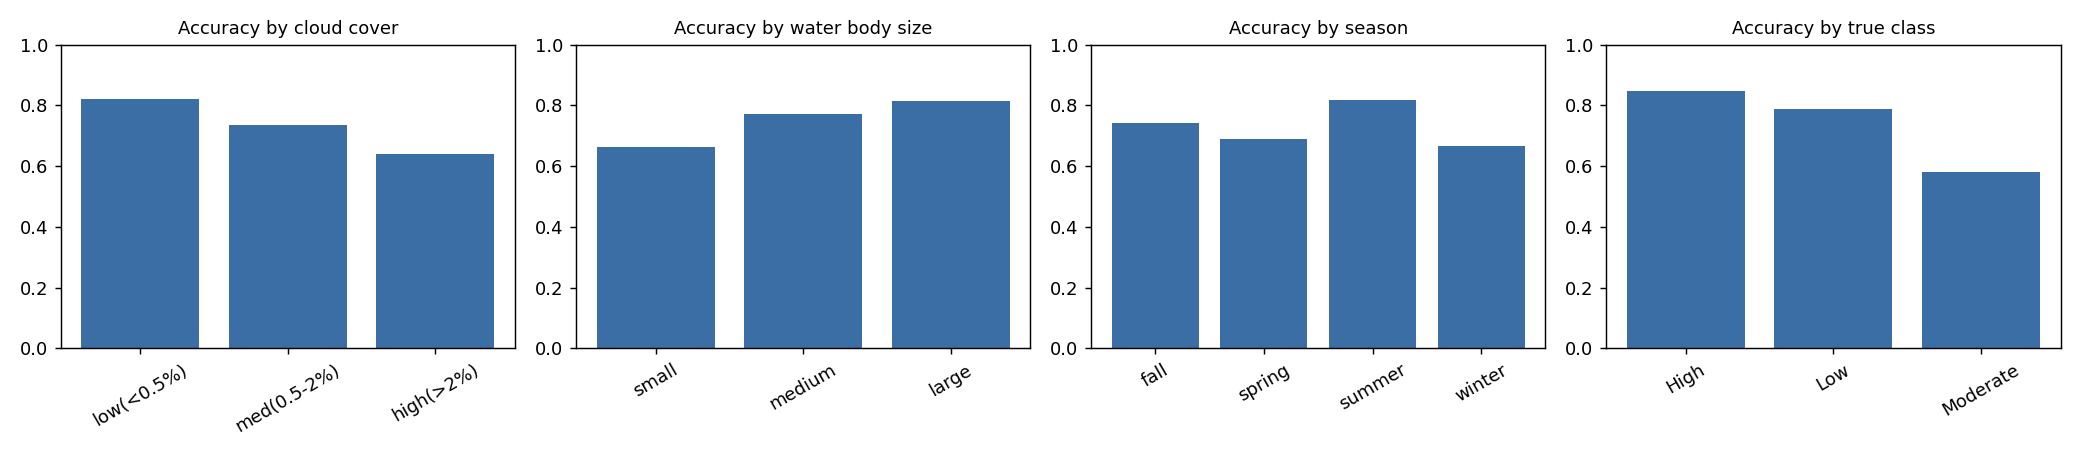

In [1]:
# stratified accuracy: cloud cover, water-body size, season, per-class


**by_cloud_cover**

- low(<0.5%): 0.820
- med(0.5-2%): 0.737
- high(>2%): 0.638

**by_water_body_size**

- small: 0.662
- medium: 0.772
- large: 0.815

**by_season**

- fall: 0.743
- spring: 0.689
- summer: 0.817
- winter: 0.667

**by_category**

- with_measurments: 0.801
- without_measurments: 0.713


**Known dataset-level biases (from the dataset card, not something modeling can fix):**

- **Geographic bias:** locations come from the CAML dataset's North American sampling sites only; the model will not necessarily generalize to lakes on other continents or with different water chemistry.
- **Taxonomic specificity:** labels target *cyanobacterial* blooms specifically; other HAB-forming organisms (e.g. some marine algae) have different optical signatures and would not be reliably detected by this model.
- **Inherited label noise:** for tiles without direct in-situ measurement, the label was itself produced by the CyFi model, not ground truth — our model partially learns to imitate CyFi rather than the true underlying phenomenon in those cases.
- **Tile-level label vs. patchy blooms:** a tile is labeled `High` if *any* part of it has a high-severity bloom, even if most of the water body is clear (see the example map below) — so a model trained on whole-tile statistics is being asked to detect sometimes-localized events from an averaged signal, which caps achievable recall on `High`.
- **Class imbalance:** High (1958) > Low (1401) > Moderate (1339); macro-F1 is reported specifically because accuracy alone would overweight the majority class.

## 4. Model selection for deployment

**Recommended model: `random_forest`.** See `reports/REPORT.md` for the full writeup, including strengths/weaknesses and concrete next steps.